# Notebook 01 — Pipeline de Datos

## Objetivo

Construye la base del proyecto: carga los tres datasets crudos, calcula los indicadores técnicos y macroeconómicos, define la variable objetivo y guarda el resultado en `data/processed/sp500_features.csv`.

El output de este notebook va a ser el input de todos los notebooks siguientes. Está pensado para correrse **una sola vez** (o cuando se quiera regenerar los datos desde cero). Los notebooks de modelado cargan directamente el CSV procesado sin necesidad de re-ejecutar este pipeline.

**¿Por qué separar el pipeline del análisis?** Porque el procesamiento de datos es determinístico: si los datos crudos no cambian, el output tampoco cambia. Separarlo evita recalcular features cada vez que exploramos un modelo.

In [1]:
import sys
import os
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src import data_loader, features, utils

utils.set_plot_style()

# Rutas base
RAW_DIR       = "../data/raw"
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

## Fuentes de datos

Usamos tres fuentes complementarias que cubren distintas dimensiones del mercado.
Los CSVs en `data/raw/` ya contienen el período completo (2008–2025):

| Dataset | Fuente | Frecuencia | Período (pool modelado) |
|---|---|---|---|
| Precios S&P 500 | yfinance (`^GSPC`) | Diaria (días de trading) | 2008–2025 |
| Indicadores macro | FRED API | VIX/T10Y2Y diarios; FEDFUNDS/CPI/UNRATE mensuales | 2008–2025 |
| Noticias financieras | Kaggle + extensión scrapeada | Múltiples por día | 2008–2025 |

Los últimos ~6 meses de cada fuente quedan reservados en un set de "producción"
separado (`*_production.csv`), fuera de este pool — se usan para demostrar el
modelo en vivo, no para entrenar/validar/testear.

Los datos crudos están en `data/raw/` y **nunca se modifican**. Todo el procesamiento genera archivos nuevos en `data/processed/`.

In [2]:
# Carga de los tres datasets
sp500 = data_loader.load_sp500(RAW_DIR)
macro = data_loader.load_macro(RAW_DIR)
news  = data_loader.load_news(RAW_DIR)

print(f"S&P 500:  {sp500.shape} | {sp500.index[0].date()} → {sp500.index[-1].date()}")
print(f"Macro:    {macro.shape} | {macro.index[0].date()} → {macro.index[-1].date()}")
print(f"Noticias: {news.shape}  | {news['Date'].min().date()} → {news['Date'].max().date()}")

S&P 500:  (4522, 5) | 2008-01-02 → 2025-12-19
Macro:    (4750, 5) | 2008-01-01 → 2025-12-19
Noticias: (27212, 2)  | 2008-01-02 → 2025-12-18


## Construcción de indicadores técnicos

Los indicadores técnicos son transformaciones de los precios históricos que capturan **momentum**, **tendencia** y **volatilidad** del mercado. Son las features más directamente relacionadas con el comportamiento del S&P 500:

- **RSI_14** (momentum): mide si el mercado está sobrecomprado (>70) o sobrevendido (<30) en los últimos 14 días. Valores extremos tienden a revertir.
- **MACD** (momentum/tendencia): diferencia entre la EMA de 12 días y la de 26 días. Positivo = momentum alcista.
- **BB_position** (volatilidad): posición del precio dentro de las Bandas de Bollinger de 20 días. Valores cercanos a 0 indican que el precio está en la banda inferior.
- **return_1d**: retorno del día anterior — captura el efecto de reversión/momentum de corto plazo.
- **return_5d**: retorno de la semana anterior — tendencia de mediano plazo.
- **volume_change**: variación del volumen — un aumento de volumen con movimiento de precio suele confirmar la tendencia.

Los primeros ~26 días quedarán en NaN por la ventana del MACD. Los eliminamos al final del pipeline.

In [3]:
# Calcular indicadores técnicos sobre los precios del S&P 500
sp500_features_df = features.add_technical_indicators(sp500)

print(f"Shape después de indicadores técnicos: {sp500_features_df.shape}")
print(f"Nuevas columnas: {[c for c in sp500_features_df.columns if c not in sp500.columns]}")
sp500_features_df.tail(3)

Shape después de indicadores técnicos: (4522, 11)
Nuevas columnas: ['RSI_14', 'MACD', 'BB_position', 'return_1d', 'return_5d', 'volume_change']


,Close,High,Low,Open,Volume,RSI_14,MACD,BB_position,return_1d,return_5d,volume_change
Date,,,,,,,,,,,
2025-12-17,6721.430176,6812.259766,6720.430176,6802.879883,5122120000,42.893888,16.858177,0.328191,-0.011592,-0.023996,0.027882
2025-12-18,6774.759766,6816.129883,6758.500000,6778.060059,5101190000,48.412450,12.745867,0.443744,0.007934,-0.018293,-0.004086
2025-12-19,6834.500000,6840.020020,6792.620117,6792.620117,8554470000,53.798638,14.144322,0.587349,0.008818,0.001038,0.676956


## Integración de indicadores macroeconómicos

Los indicadores macro capturan el **contexto económico** en el que opera el mercado:

- **VIX**: índice de volatilidad implícita del mercado de opciones. Valores altos indican miedo/incertidumbre.
- **T10Y2Y**: diferencial de tasas entre el bono a 10 años y el de 2 años. Cuando es negativo (yield curve invertida), históricamente precede recesiones.
- **FEDFUNDS**: tasa de fondos federales. Determina el costo del dinero en la economía.
- **CPI**: inflación. Alta inflación suele presionar al mercado a la baja.
- **UNRATE**: tasa de desempleo. Mercado laboral fuerte = economía sana = mercado al alza (en general).


In [4]:
# Merge con macro: reindexar al calendario de trading + forward fill para mensuales
sp500_with_macro = features.add_macro_features(sp500_features_df, macro)

print(f"Shape con macro: {sp500_with_macro.shape}")
print(f"Nulls por columna (macro):\n{sp500_with_macro[['vix','t10y2y','fedfunds','cpi','unrate']].isnull().sum()}")

Shape con macro: (4522, 16)
Nulls por columna (macro):
vix          0
t10y2y       0
fedfunds     0
cpi         29
unrate      21
dtype: int64


## Variable objetivo

Definimos el **target** como:

$$\text{target}_t = \begin{cases} 1 & \text{si } \text{Close}_{t+1} > \text{Close}_t \\ 0 & \text{si no} \end{cases}$$

Es decir, **1 si el mercado cierra arriba mañana, 0 si cierra igual o abajo**. Esto es un problema de **clasificación binaria**.

**Importante**: el target se calcula con `shift(-1)` sobre el precio de cierre, lo que significa que el modelo usa las features de hoy para predecir si el precio de mañana será más alto que el de hoy. La última fila se elimina porque no tiene target conocido.

El mercado sube aproximadamente el 53% de los días hábiles (en un mercado con tendencia alcista de largo plazo), lo que genera un **leve desbalance de clases** que vamos a manejar con `class_weight='balanced'` en LR y `scale_pos_weight` en XGBoost.


Distribución del target:
  Sube (1): 2,463 días (54.5%)
  Baja (0): 2,058 días (45.5%)


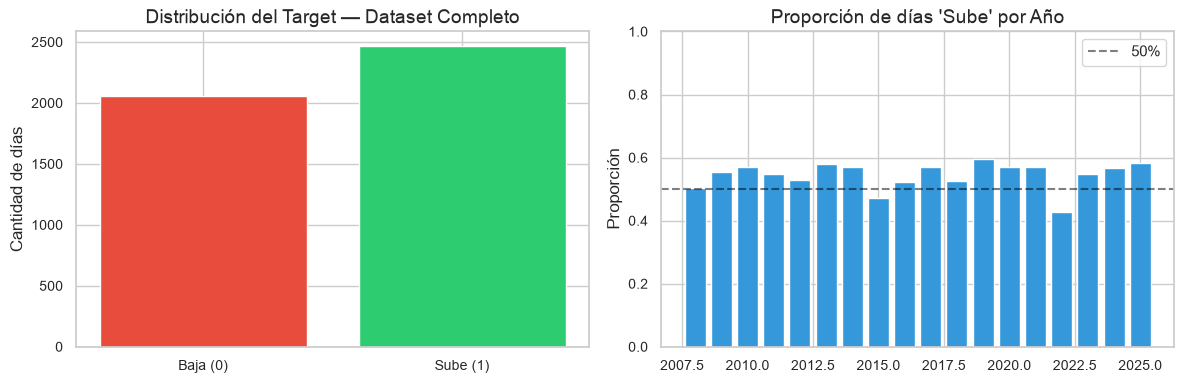

In [5]:
# Calcular target y eliminar última fila
sp500_final = features.compute_target(sp500_with_macro)

# Distribución del target
conteo = sp500_final["target"].value_counts()
print(f"\nDistribución del target:")
print(f"  Sube (1): {conteo[1]:,} días ({conteo[1]/len(sp500_final)*100:.1f}%)")
print(f"  Baja (0): {conteo[0]:,} días ({conteo[0]/len(sp500_final)*100:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Baja (0)", "Sube (1)"], [conteo[0], conteo[1]], color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Distribución del Target — Dataset Completo")
axes[0].set_ylabel("Cantidad de días")

# Proporción por año
prop_por_año = sp500_final.groupby(sp500_final.index.year)["target"].mean()
axes[1].bar(prop_por_año.index, prop_por_año.values, color="#3498db")
axes[1].axhline(0.5, color="black", linestyle="--", alpha=0.5, label="50%")
axes[1].set_title("Proporción de días 'Sube' por Año")
axes[1].set_ylabel("Proporción")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

## Guardado del dataset procesado

Guardamos el resultado en `data/processed/sp500_features.csv`. Este archivo incluye:
- Los precios originales (Close, High, Low, Open, Volume)
- Los 6 indicadores técnicos
- Los 5 indicadores macro (con forward fill aplicado)
- La variable objetivo `target`

**No incluye** el sentiment — eso se agrega en el notebook 05 cuando se construye la `feature_matrix.csv` final.

Los primeros ~26 días con NaN en los indicadores técnicos se eliminan al llamar a `build_feature_matrix()` en el notebook 05.

In [6]:
# Guardar dataset procesado
save_path = os.path.join(PROCESSED_DIR, "sp500_features.csv")
sp500_final.to_csv(save_path)

print(f"\nsp500_features.csv guardado en {save_path}")
print(f"Shape final: {sp500_final.shape}")
print(f"Período: {sp500_final.index[0].date()} → {sp500_final.index[-1].date()}")
print(f"\nColumnas:")
for col in sp500_final.columns:
    n_null = sp500_final[col].isnull().sum()
    print(f"  {col:<20} nulls={n_null}")


sp500_features.csv guardado en ../data/processed/sp500_features.csv
Shape final: (4521, 17)
Período: 2008-01-02 → 2025-12-18

Columnas:
  Close                nulls=0
  High                 nulls=0
  Low                  nulls=0
  Open                 nulls=0
  Volume               nulls=0
  RSI_14               nulls=14
  MACD                 nulls=0
  BB_position          nulls=19
  return_1d            nulls=1
  return_5d            nulls=5
  volume_change        nulls=2
  vix                  nulls=0
  t10y2y               nulls=0
  fedfunds             nulls=0
  cpi                  nulls=29
  unrate               nulls=21
  target               nulls=0
